In [ ]:
# doublet / mitochondria screen function

In [4]:
from collections import Counter
import gzip
import pathlib

import torch
import pandas as pd
import scipy
import numpy as np

import scanpy as sc
import anndata as ad
import gseapy

import seaborn as sns
import matplotlib.pyplot as plt

import flipcrow
import flipcrow.paths
import flipcrow.scp1644_mothership as mship

mps_device = torch.device("mps")

# sc.settings.verbosity = 0
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
scp1644_raw = mship.load_scp1644_data(check_metadata=True)

25.290961980819702
Checking metadata!
Biosample IDs
Counter({'PANFR0489R_Biopsy_None': 2344, 'PANFR0592_Biopsy_None': 2103, 'PANFR0557_Biopsy_None': 1863, 'PANFR0473_Biopsy_None': 1370, 'PANFR0545_Biopsy_None': 1318, 'PANFR0604_Biopsy_None': 1277, 'PANFR0580_Biopsy_None': 1243, 'PANFR0593_Biopsy_None': 1170, 'PANFR0562_Biopsy_None': 1140, 'PANFR0552_Biopsy_None': 1112, 'PANFR0576_Biopsy_None': 1011, 'PANFR0383_Biopsy_None': 1008, 'PANFR0635_Biopsy_None': 964, 'PANFR0575_Biopsy_None': 867, 'PANFR0637_Biopsy_None': 862, 'PANFR0605_Biopsy_None': 848, 'PANFR0598_Biopsy_None': 792, 'PANFR0631_Biopsy_None': 789, 'PANFR0578_Biopsy_None': 659, 'PANFR0543_Biopsy_None': 620, 'PANFR0583_Biopsy_None': 492, 'PANFR0526_Biopsy_None': 262, 'PANFR0489_Biopsy_None': 213, 'PANFR0588_Biopsy_None': 85})
Cell tags
Counter({'Biopsy_PANFR0489': 2557, 'Biopsy_PANFR0592': 2103, 'Biopsy_PANFR0557': 1863, 'Biopsy_PANFR0473': 1370, 'Biopsy_PANFR0545': 1318, 'Biopsy_PANFR0604': 1277, 'Biopsy_PANFR0580': 1243, 'Biop

In [5]:
# scp1644_raw.write_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_raw.h5ad")
scp1644_raw = ad.read_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_raw.h5ad")

In [7]:
scp1644_trim = mship.pp_scp1644_data(scp1644_raw)

Per chunk QC
Concatenate
PANFR0489_Biopsy_None : (205, 16814)
PANFR0473_Biopsy_None : (1362, 16814)
PANFR0578_Biopsy_None : (659, 16814)
PANFR0575_Biopsy_None : (866, 16814)
PANFR0593_Biopsy_None : (1170, 16814)
PANFR0383_Biopsy_None : (987, 16814)
PANFR0526_Biopsy_None : (254, 16814)
PANFR0598_Biopsy_None : (792, 16814)
PANFR0543_Biopsy_None : (609, 16814)
PANFR0576_Biopsy_None : (1011, 16814)
PANFR0583_Biopsy_None : (492, 16814)
PANFR0489R_Biopsy_None : (2340, 16814)
PANFR0592_Biopsy_None : (2101, 16814)
PANFR0604_Biopsy_None : (1277, 16814)
PANFR0580_Biopsy_None : (1242, 16814)
PANFR0605_Biopsy_None : (847, 16814)
PANFR0557_Biopsy_None : (1857, 16814)
PANFR0637_Biopsy_None : (860, 16814)
PANFR0588_Biopsy_None : (81, 16814)
PANFR0631_Biopsy_None : (787, 16814)
PANFR0545_Biopsy_None : (1318, 16814)
PANFR0562_Biopsy_None : (1138, 16814)
PANFR0552_Biopsy_None : (1105, 16814)
PANFR0635_Biopsy_None : (964, 16814)

Merged QC
Scrublet
Dimensionality reduction and clustering
HVG + Rank genes

In [8]:
scp1644_trim.write_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_trim.h5ad")
# scp1644_trim = ad.read_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_trim.h5ad")

In [9]:
print(scp1644_trim)

AnnData object with n_obs × n_vars = 24323 × 16604
    obs: 'biosample_id', 'donor_ID', 'Genes', 'UMI', 'dataset', 'sample.type', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'Coarse_Cell_Annotations', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'u400genes', 'u1000counts', 'o50mtpct', 'o8000genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'low_qual_u50cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'tsne', 'hvg', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'trimmed

In [6]:
sc.pp.pca(scp1644_trim)
sc.pp.neighbors(scp1644_trim)
sc.tl.leiden(scp1644_trim)
sc.tl.umap(scp1644_trim)
sc.tl.tsne(scp1644_trim)

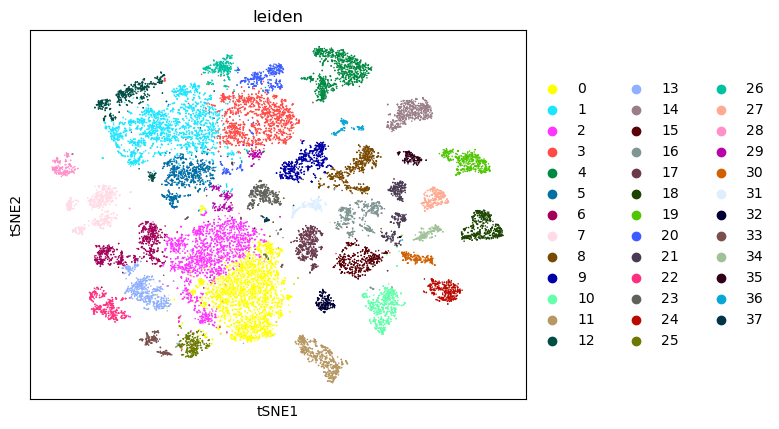

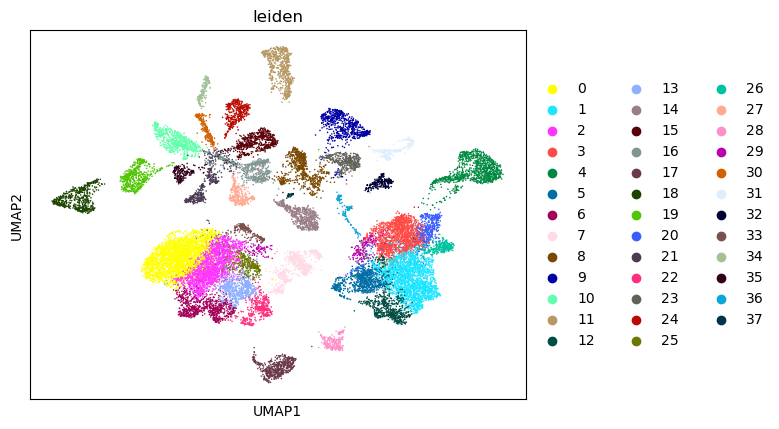

In [12]:
sc.pl.tsne(scp1644_trim, color='leiden')
sc.pl.umap(scp1644_trim, color='leiden')

In [41]:
print(vipp.droplevel(level=1, axis=1))

        pct_counts_mt  pct_counts_mt  pct_counts_mt
leiden                                             
0           11.998394       5.256728      48.061047
1            9.715414       4.405717      37.221001
2           15.757393       8.784091      49.792187
3            7.851540       5.091747      40.320942
4            5.613185       5.356910      42.205204
5            8.969259       4.026422      31.051540
6           12.076645       6.923486      49.561211
7           15.883657       6.904766      48.781609
8           13.937238       8.473916      48.060036
9            8.457111       6.257245      42.210384
10          15.760731      10.943246      49.177982
11          19.624409      11.812049      49.722363
12           9.385215       4.822981      39.619846
13          12.902106       7.656483      46.772594
14          12.802291       8.084050      49.380283
15          19.595921      11.624428      49.967365
16          12.391896       9.331692      49.216644
17          

             mean        std        max
leiden                                 
37       2.683612   7.566489  44.969906
4        5.613185   5.356910  42.205204
20       6.311971   3.320609  25.092798
26       7.309476   4.182673  32.165451
28       7.660637   4.325562  35.762482
3        7.851540   5.091747  40.320942
22       8.334223   4.957112  41.296623
9        8.457111   6.257245  42.210384
19       8.674874   6.184194  45.043831
5        8.969259   4.026422  31.051540
17       9.111616   5.827756  47.481842
12       9.385215   4.822981  39.619846
32       9.431930   6.839633  42.953259
1        9.715414   4.405717  37.221001
35      10.041408   8.268519  45.511253
18      10.948505   8.281452  45.862141
24      10.975481   8.472103  45.387180
25      11.223983   5.458033  36.983799
36      11.793521   7.930602  44.608669
0       11.998394   5.256728  48.061047
6       12.076645   6.923486  49.561211
16      12.391896   9.331692  49.216644
23      12.462424   8.666083  46.364796


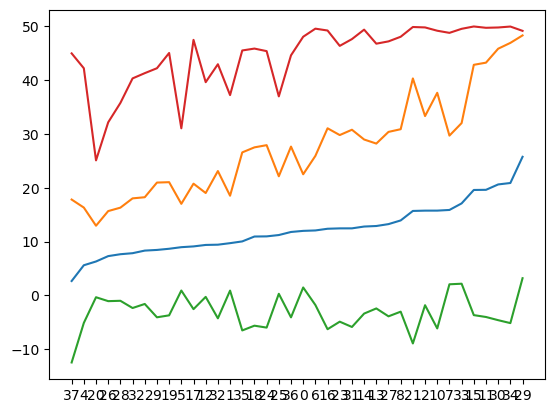

In [46]:
# leiden clustered stats of pct_counts_mt 
vipp = scp1644_trim.obs.groupby('leiden').agg({'pct_counts_mt': ['mean', 'std', 'max']}).droplevel(level=0, axis=1).sort_values('mean')
print(vipp)
plt.plot(vipp.loc[:, 'mean'])
plt.plot(vipp.loc[:, 'mean'] + 2*vipp.loc[:, 'std'])
plt.plot(vipp.loc[:, 'mean'] - 2*vipp.loc[:, 'std'])
plt.plot(vipp.loc[:, 'max'])
# print(scp1644_trim.obs.groupby('leiden').agg({'pct_counts_mt': 'mean'}))


In [ ]:
# mitoscreen with marker genes and remove worst clusters

print("HVG + Rank genes groups")
sc.pp.highly_variable_genes(scp1644_trim)
sc.tl.rank_genes_groups(scp1644_trim, 'leiden')


Perform mitoscreen
33    0.547619
29    0.476190
34    0.404762
30    0.238095
7     0.142857
15    0.142857
8     0.071429
11    0.047619
36    0.047619
35    0.047619
13    0.047619
14    0.023810
21    0.023810
27    0.023810
37    0.023810
10    0.023810
2     0.023810
31    0.000000
24    0.000000
28    0.000000
32    0.000000
26    0.000000
25    0.000000
0     0.000000
23    0.000000
22    0.000000
20    0.000000
1     0.000000
18    0.000000
17    0.000000
16    0.000000
12    0.000000
9     0.000000
6     0.000000
5     0.000000
4     0.000000
3     0.000000
19    0.000000
Name: GGB_MITOCHONDRIAL, dtype: float64


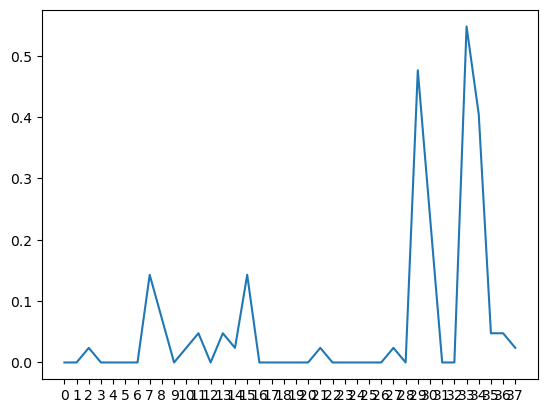

In [50]:
# mitoscreen with marker genes and remove worst clusters

print("Perform mitoscreen")
ggb_mitoscreen = {'GGB_MITOCHONDRIAL': [x for x in scp1644_trim.var_names if x.startswith('MT-') or x.startswith('MTRNR')]}
ggb_mito_result = sc.tl.marker_gene_overlap(scp1644_trim, ggb_mitoscreen, method='overlap_count', normalize='reference')

plt.plot(ggb_mito_result.loc['GGB_MITOCHONDRIAL', :])
print(ggb_mito_result.loc['GGB_MITOCHONDRIAL', :].sort_values(ascending=False))

for idx in ggb_mito_result.index:
    scp1644_trim.obs['GGB_MITOCHONDRIAL'] = [ggb_mito_result.loc['GGB_MITOCHONDRIAL', leid_idx] for leid_idx in scp1644_trim.obs['leiden']]

In [57]:
mt_cutoff = 0.1
doublet_cutoff = 0.1
scp1644_filter = scp1644_trim[np.logical_and(scp1644_trim.obs.GGB_MITOCHONDRIAL < mt_cutoff, scp1644_trim.obs.doublet_score < doublet_cutoff), :]

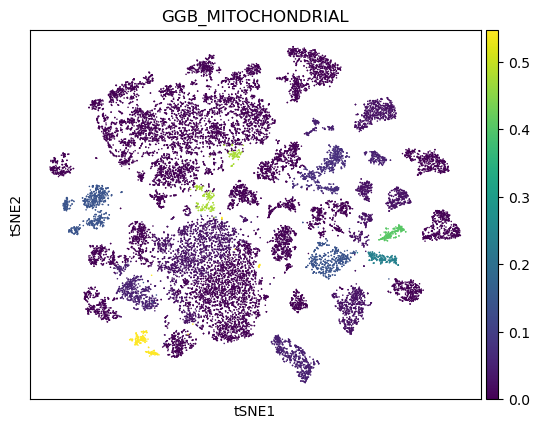

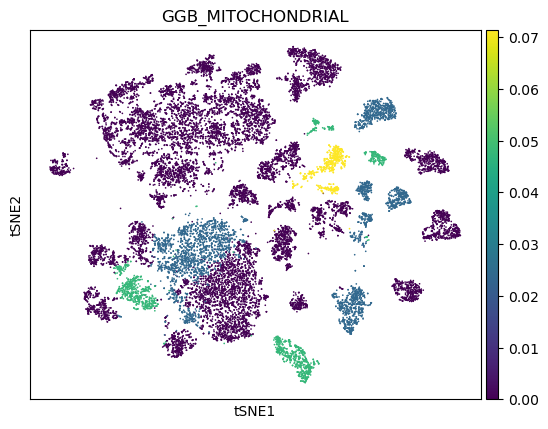

In [58]:
sc.pl.tsne(scp1644_trim, color=['GGB_MITOCHONDRIAL'])
sc.pl.tsne(scp1644_filter, color=['GGB_MITOCHONDRIAL'])

In [59]:
scp1644_filter.write_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_filter.h5ad")

In [60]:
sc.pp.pca(scp1644_filter)
sc.pp.neighbors(scp1644_filter)
sc.tl.leiden(scp1644_filter)
sc.tl.umap(scp1644_filter)
sc.tl.tsne(scp1644_filter)

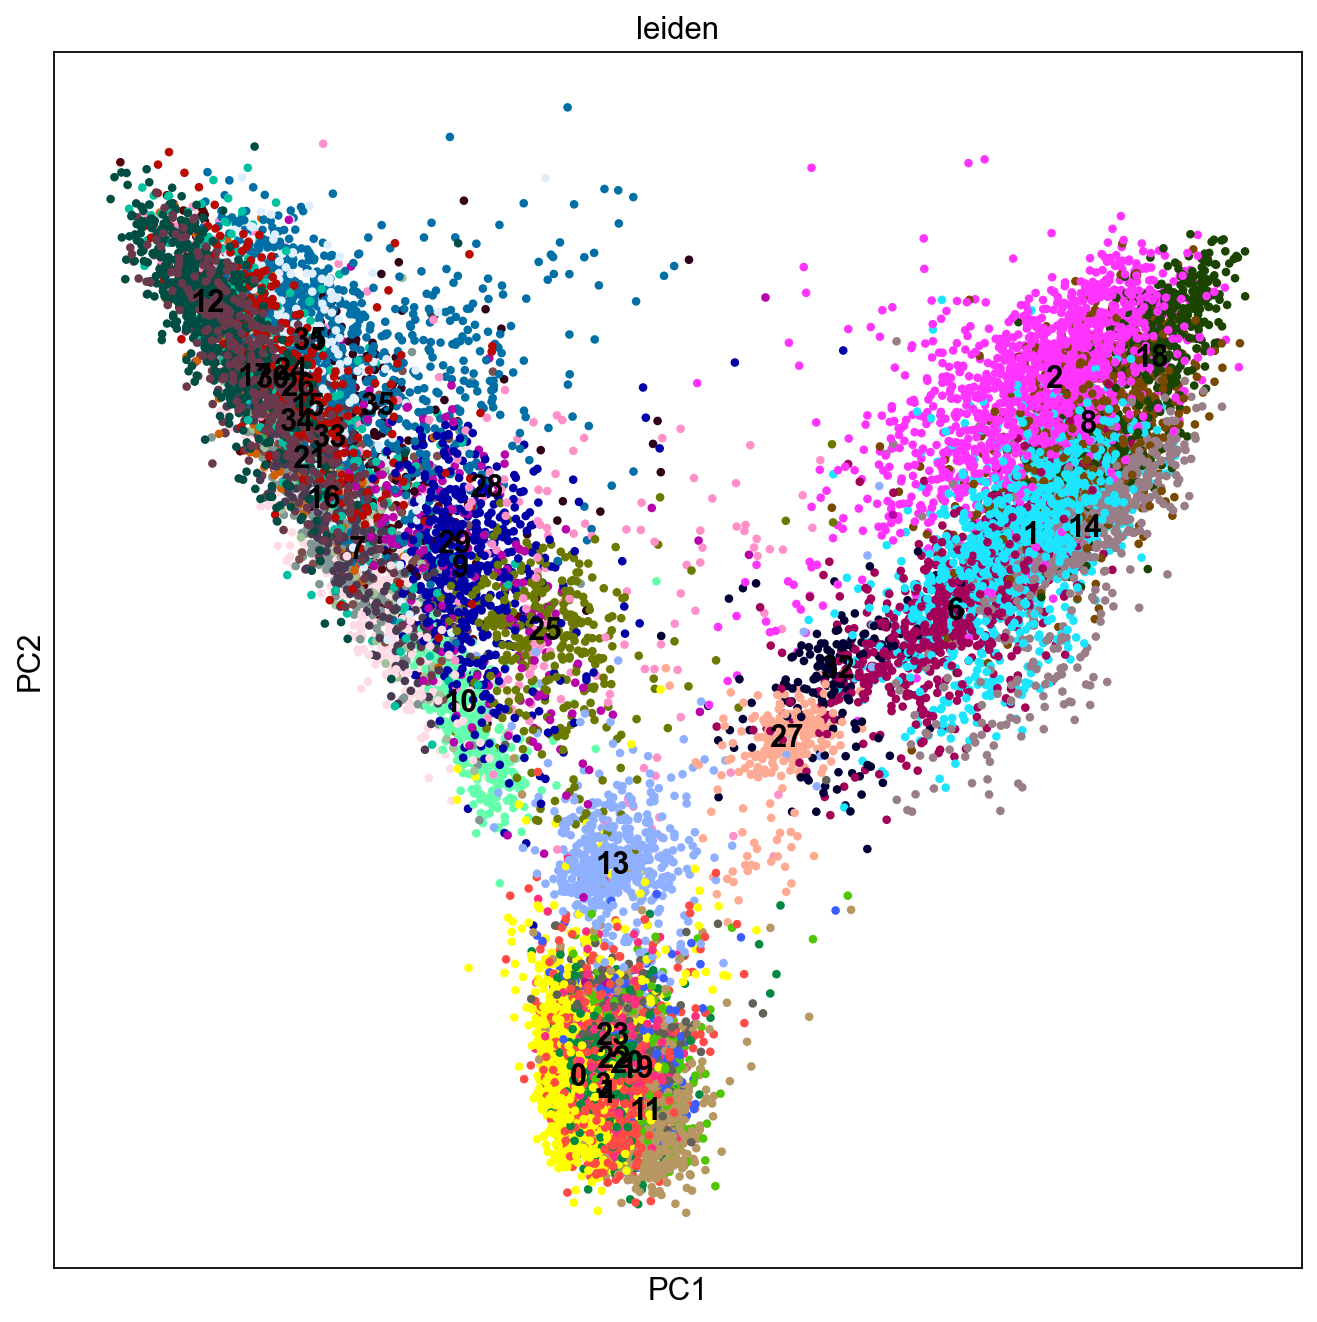

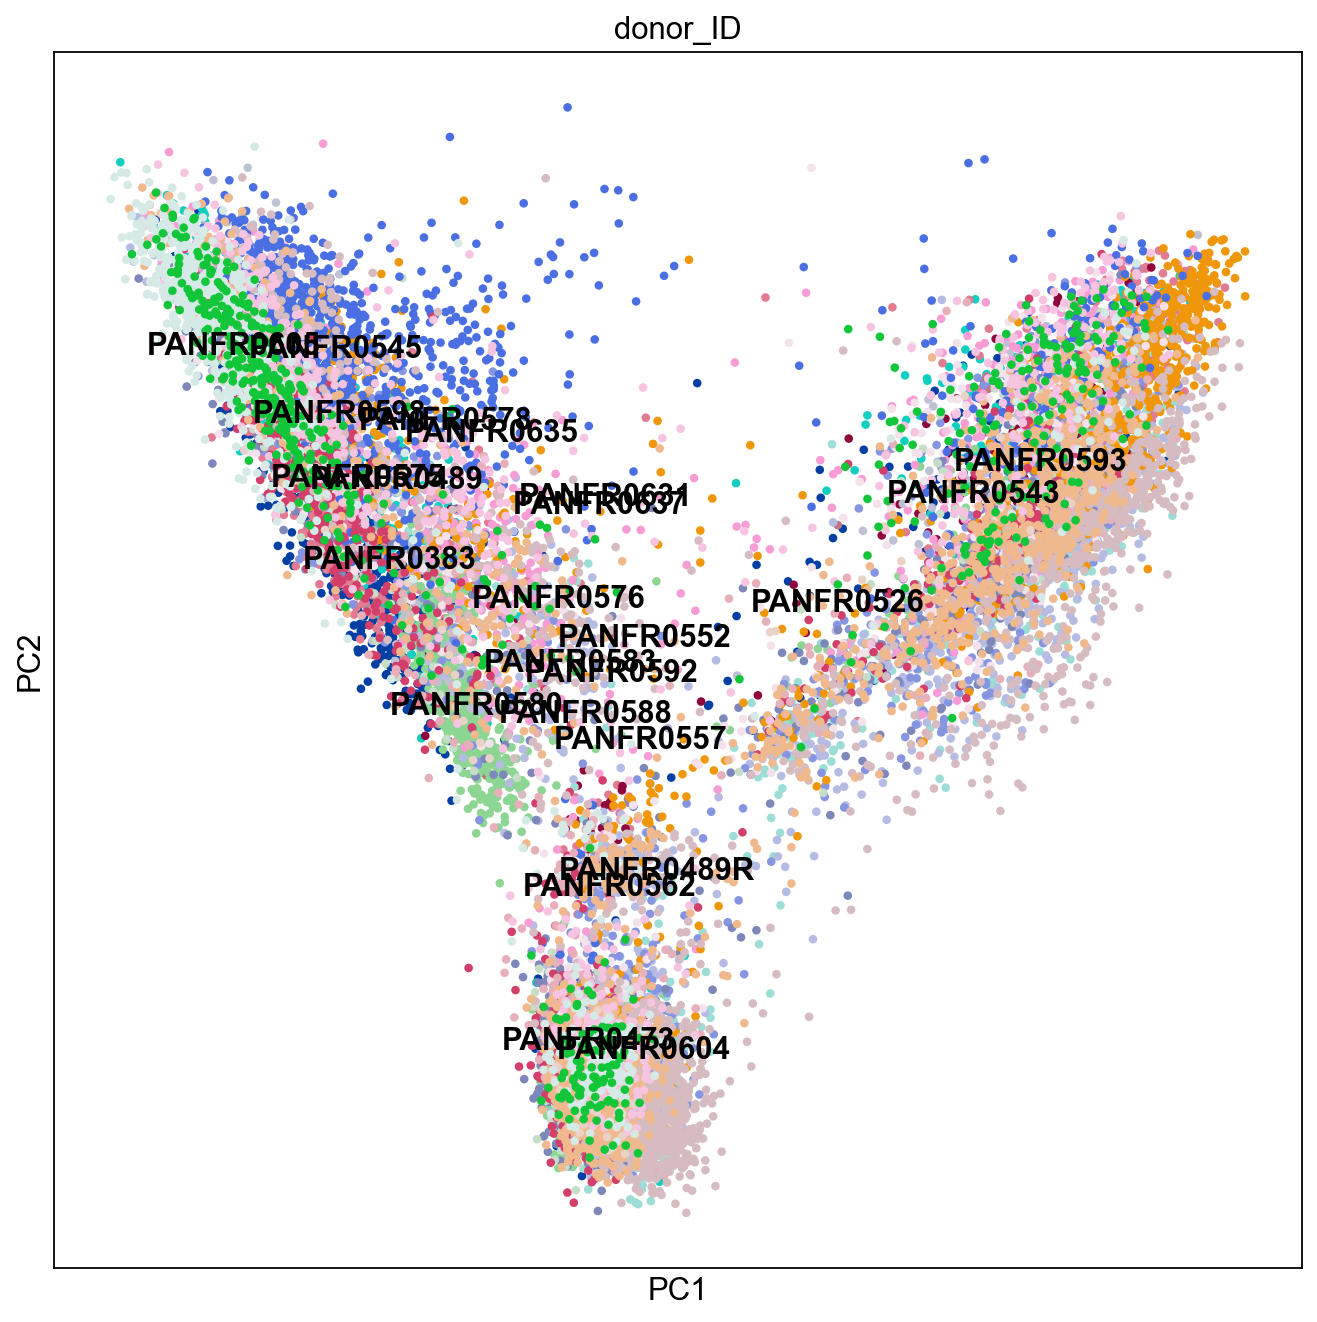

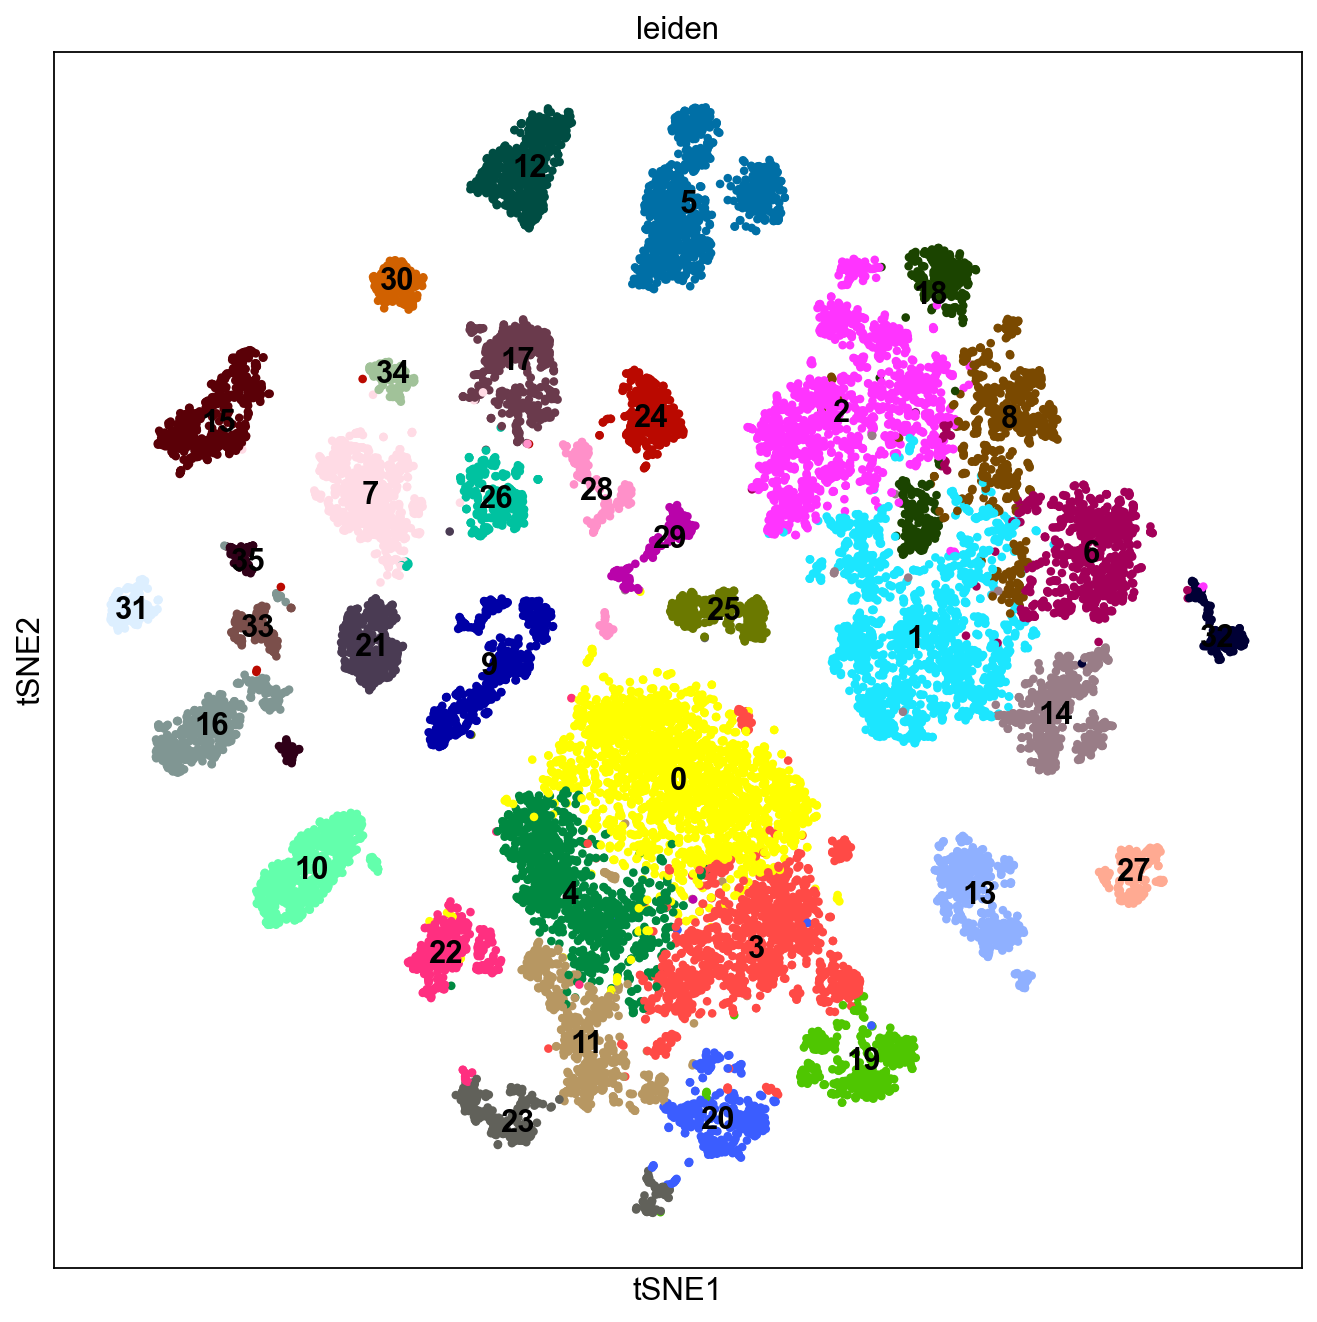

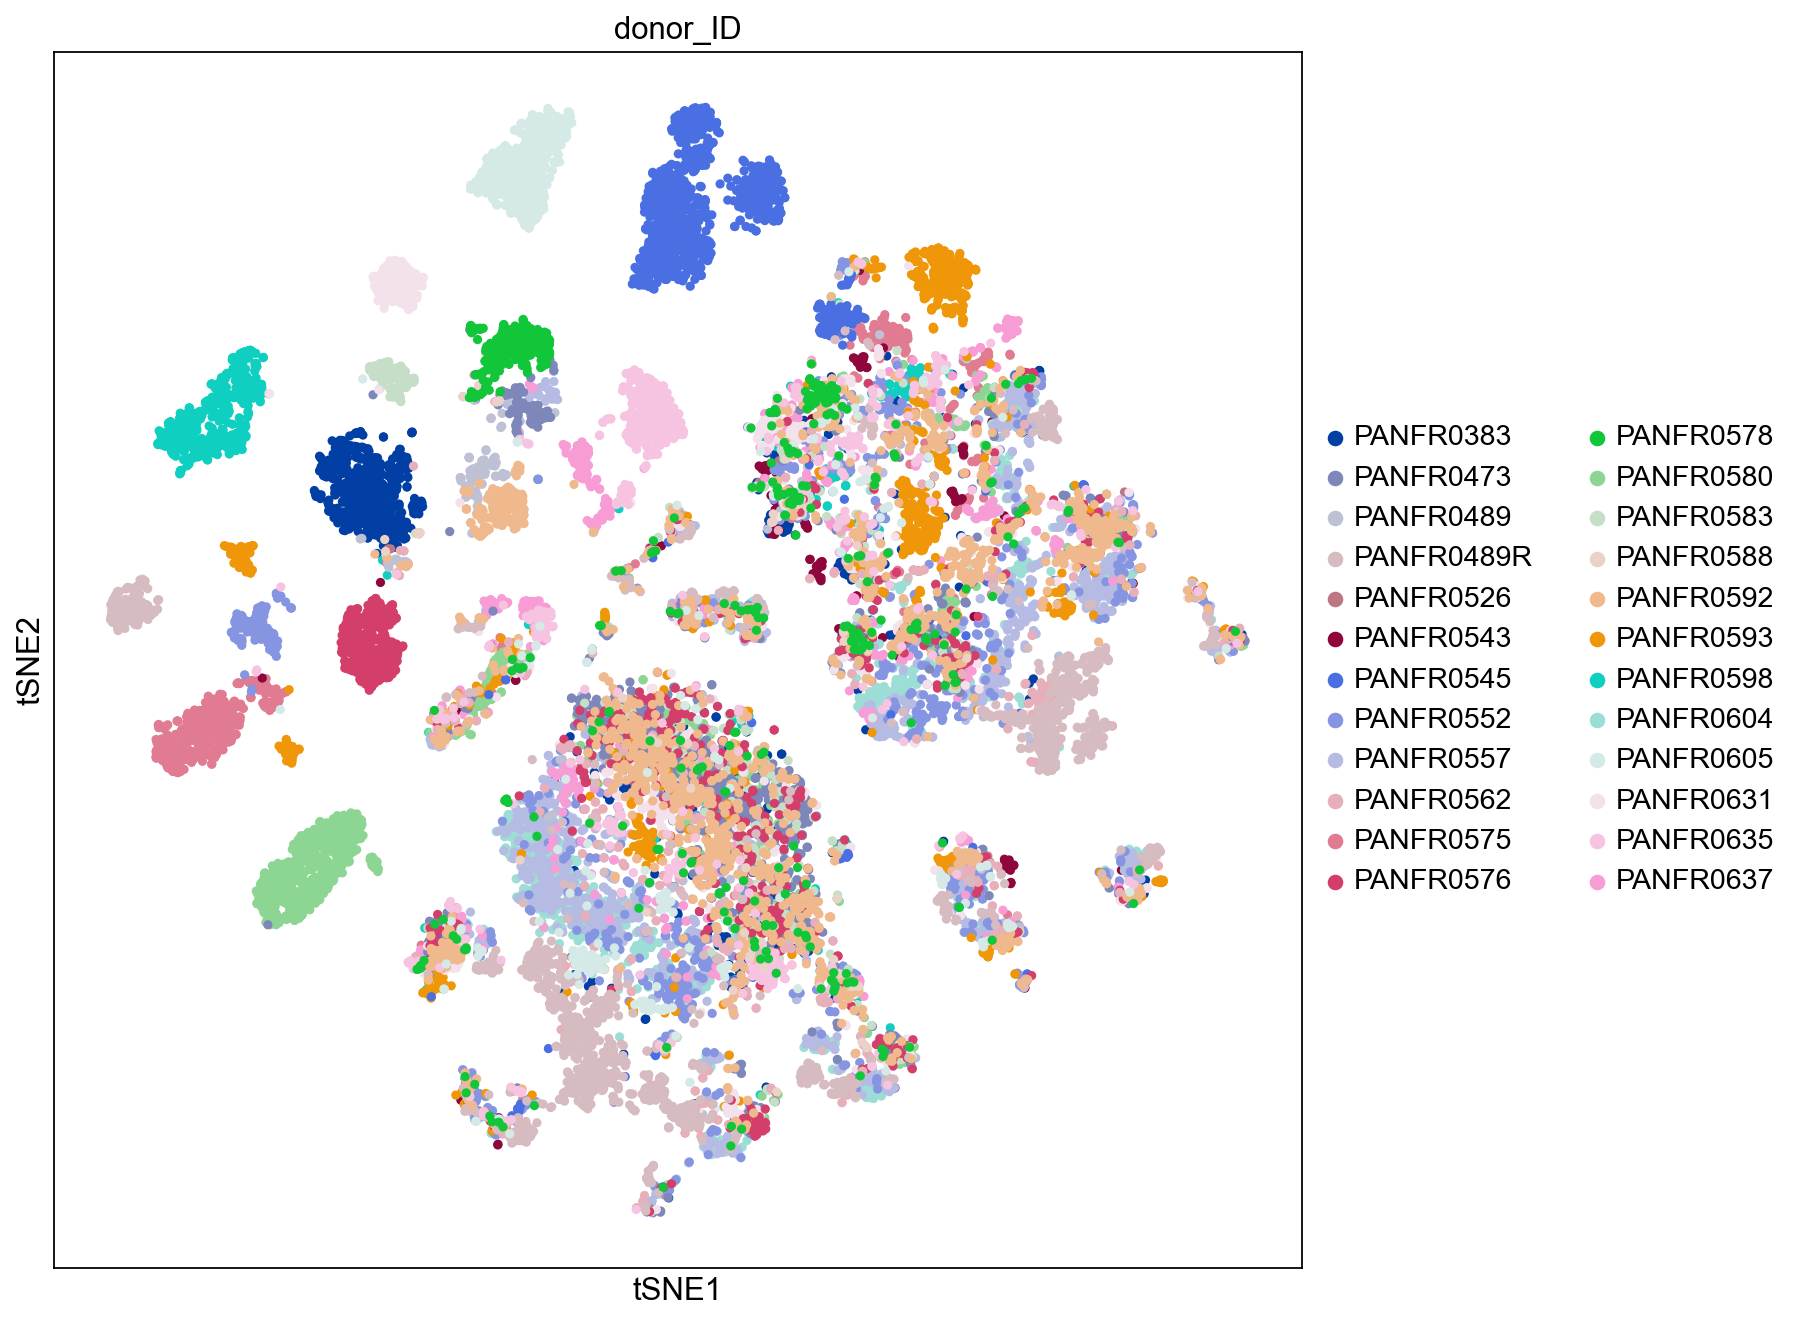

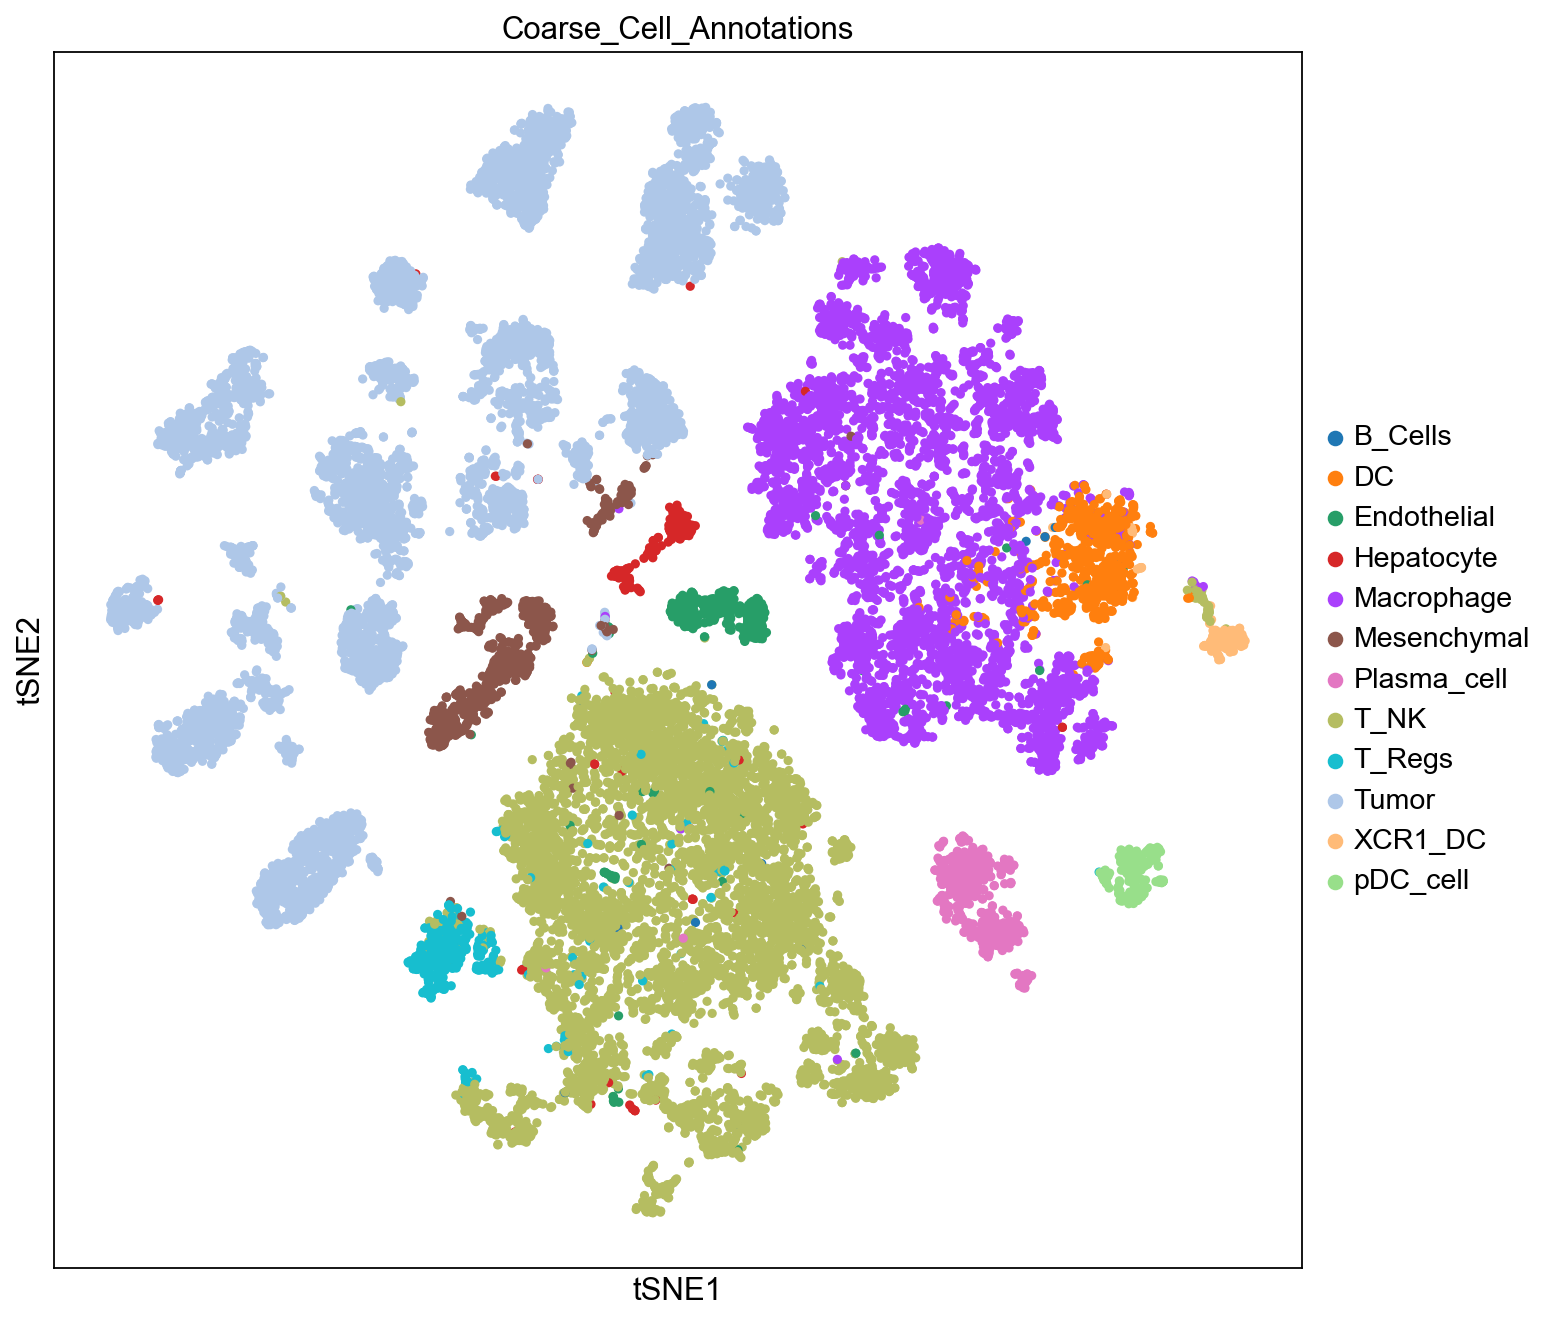

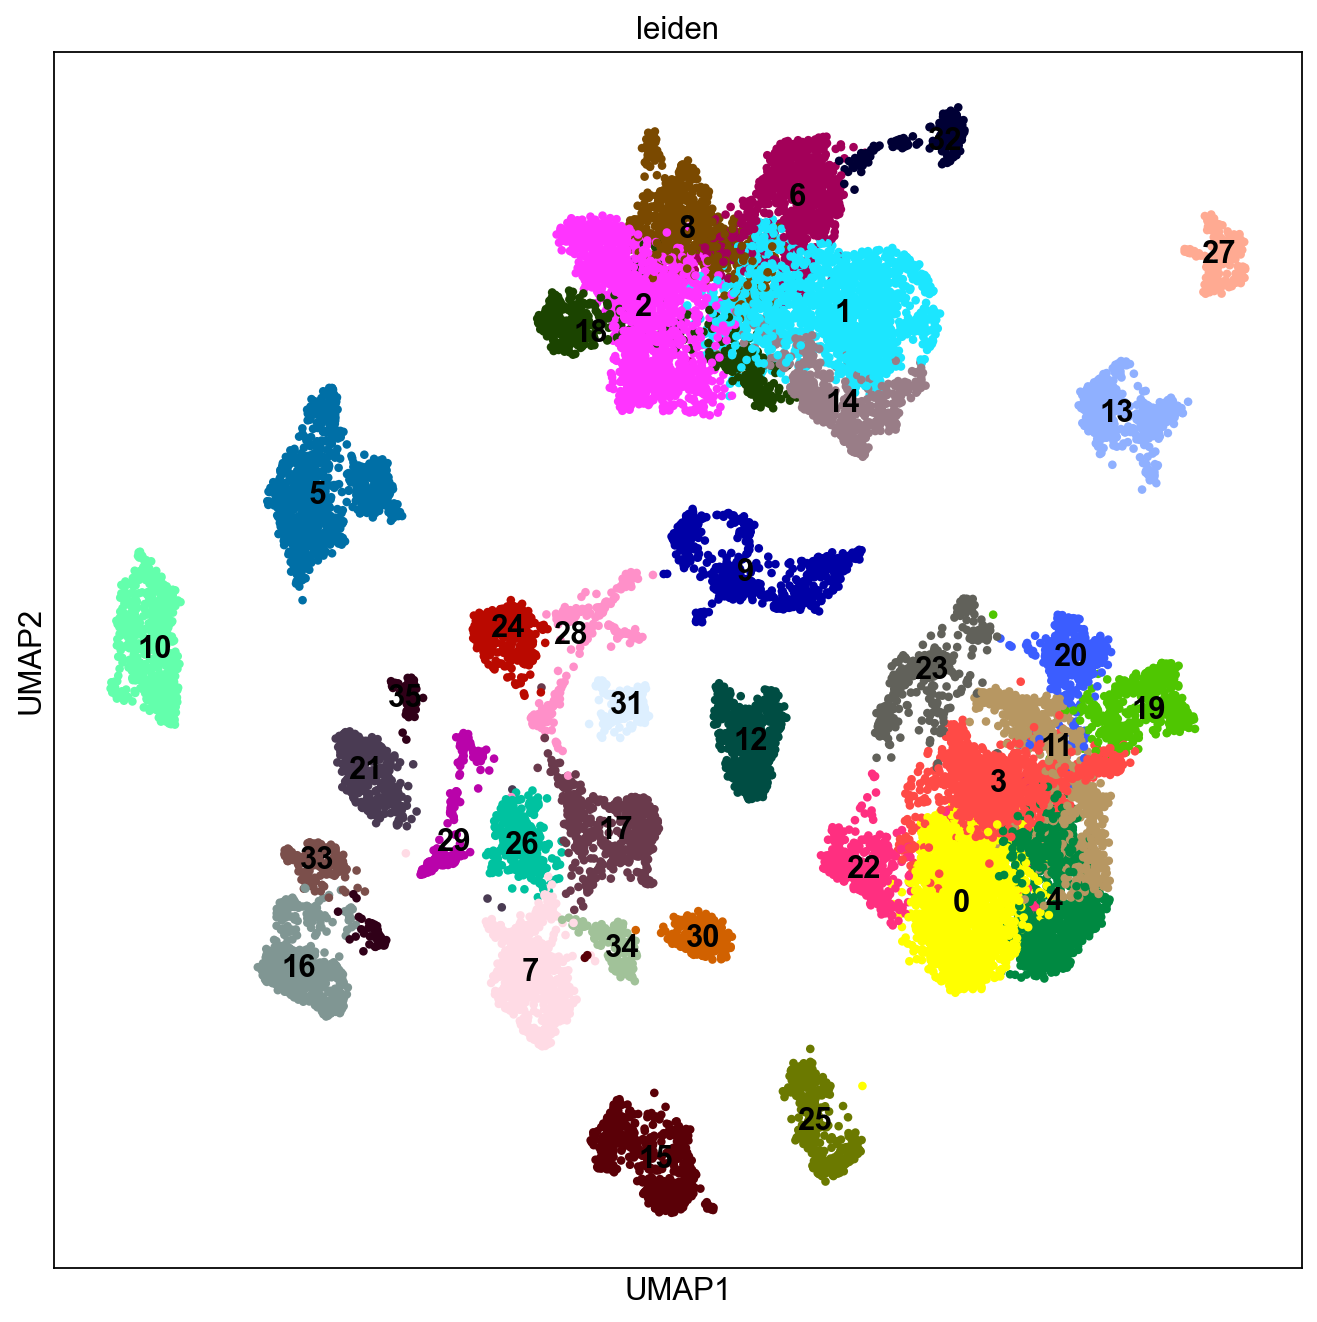

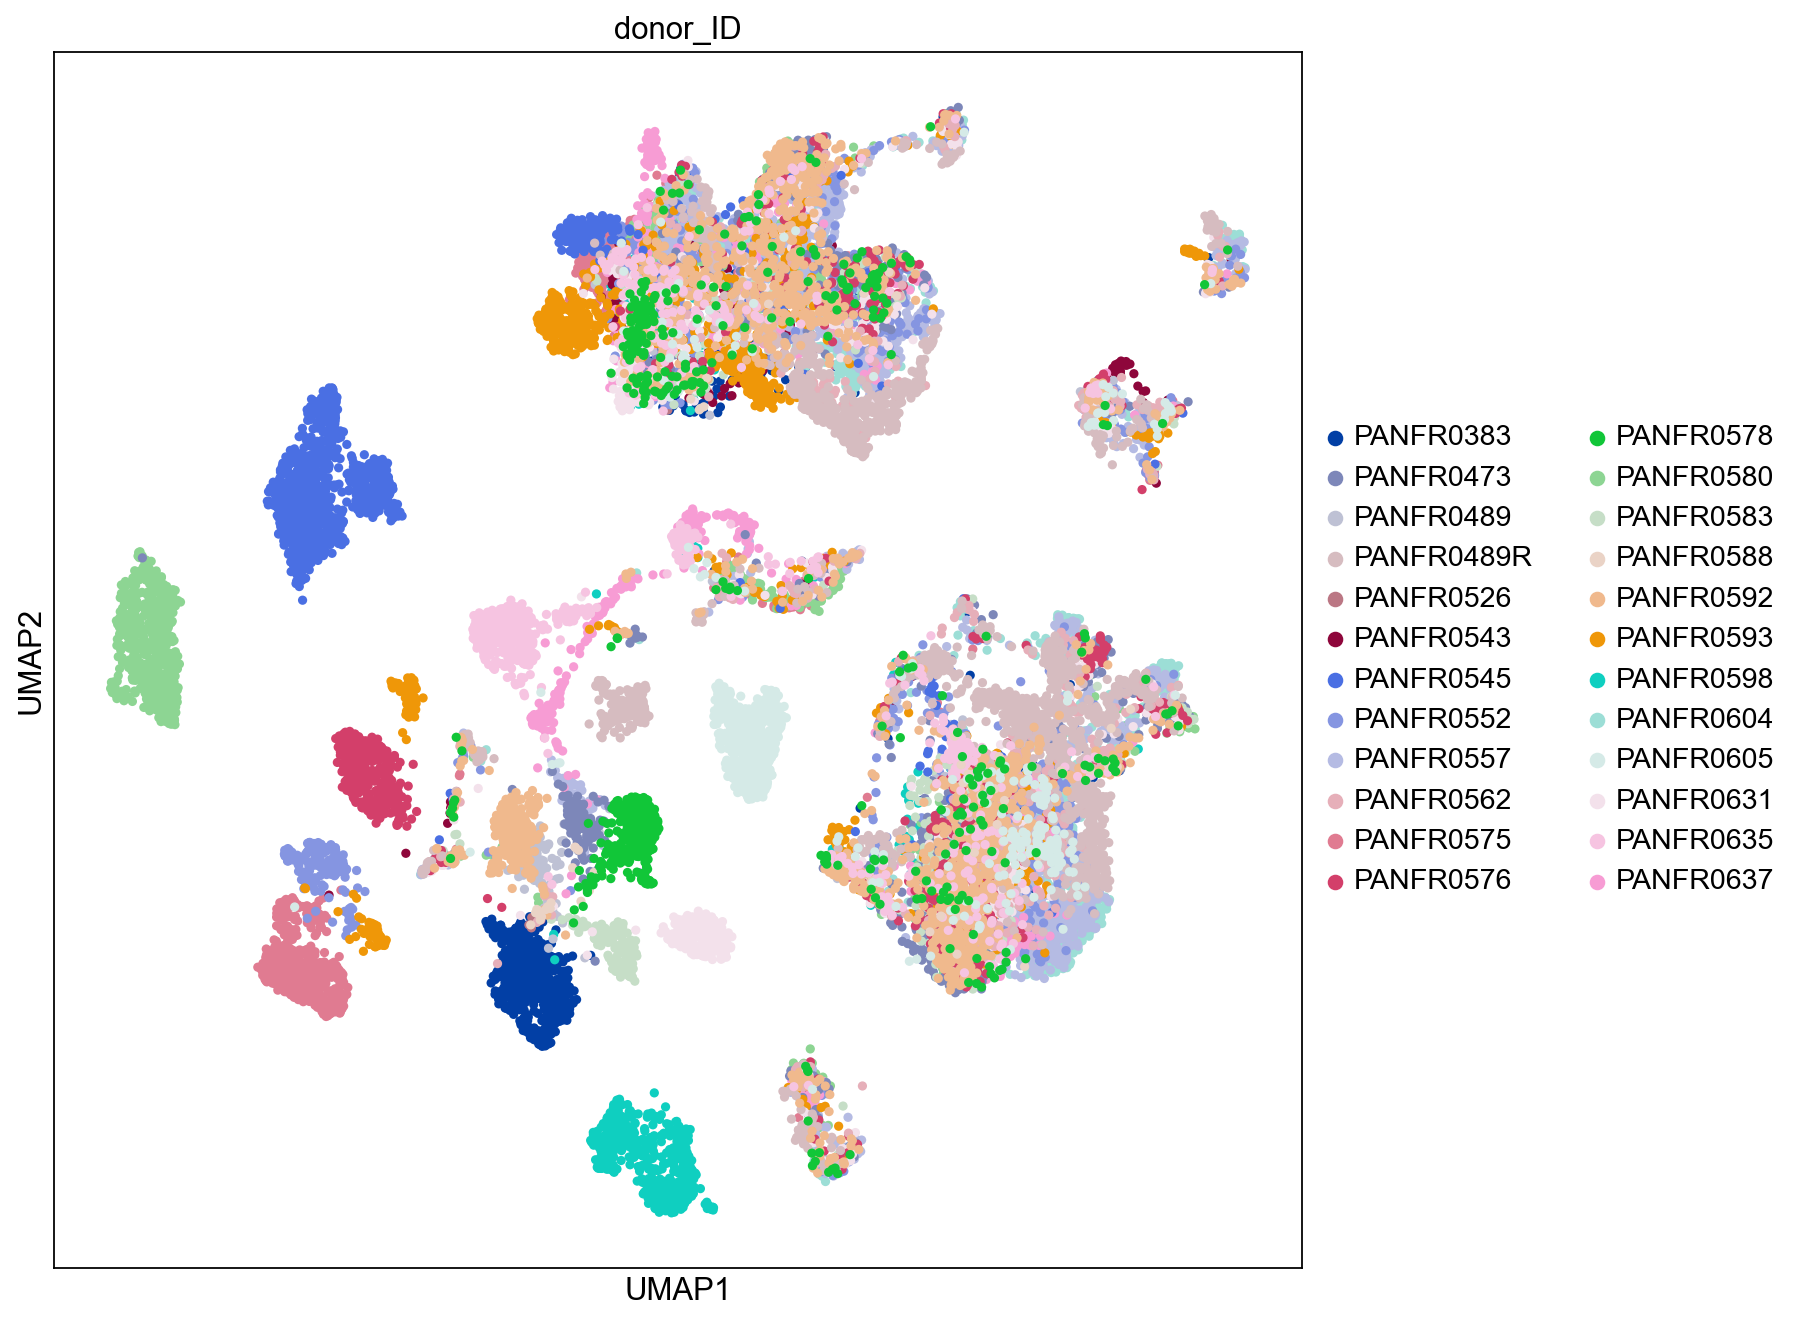

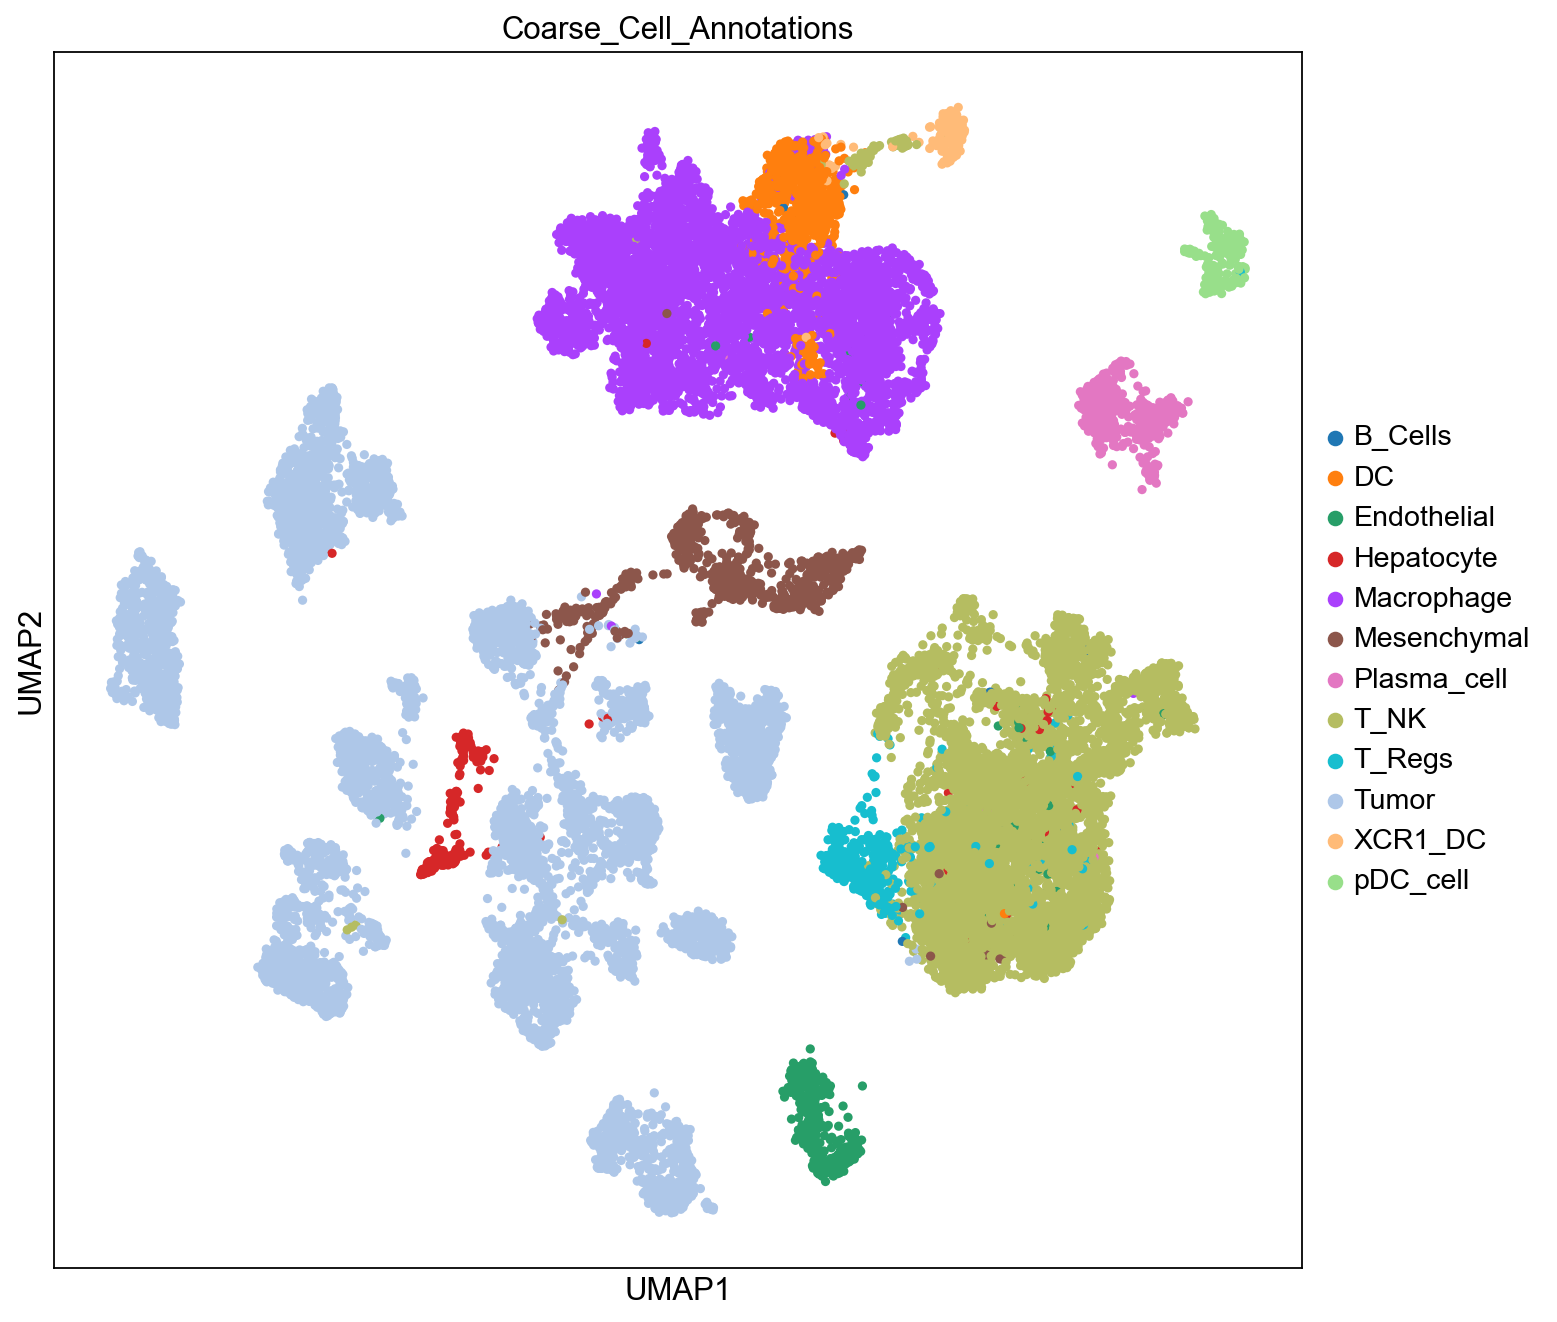

In [74]:
sc.set_figure_params(figsize=(10, 10))

sc.pl.pca(scp1644_filter, color=['leiden'], legend_loc="on data", size=60)
sc.pl.pca(scp1644_filter, color=['donor_ID'], legend_loc="on data", size=60)
sc.pl.tsne(scp1644_filter, color=['leiden'], legend_loc="on data", size=60)
sc.pl.tsne(scp1644_filter, color='donor_ID', size=69)
sc.pl.tsne(scp1644_filter, color='Coarse_Cell_Annotations', size=69)
sc.pl.umap(scp1644_filter, color=['leiden'], legend_loc="on data", size=60)
sc.pl.umap(scp1644_filter, color='donor_ID', size=69)
sc.pl.umap(scp1644_filter, color='Coarse_Cell_Annotations', size=69)

In [5]:
# mship.norm_log_xform_scp1644_data(scp1644_trim)
# scp1644_trim.write_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_log.h5ad")

# print(scp1644_raw)
# print(scp1644_trim)


AnnData object with n_obs × n_vars = 24412 × 16814
    obs: 'biosample_id', 'donor_ID', 'Genes', 'UMI', 'dataset', 'sample.type', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'Coarse_Cell_Annotations'
AnnData object with n_obs × n_vars = 24323 × 16604
    obs: 'biosample_id', 'donor_ID', 'Genes', 'UMI', 'dataset', 'sample.type', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'Coarse_Cell_Annotations', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'u400genes', 'u1000counts', 'o50mtpct', 'o8000genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 